In [4]:
%pip install numpy matplotlib pandas scipy astropy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.special  import gamma
from astropy import constants as const
from astropy import units as u


In [6]:
data_m82spec = pd.read_csv("m82spec.txt", sep=r"\s+", engine="python",skiprows=1,names=["lambda (micron)","Lnu (Lsun/Hz)","sigmaLnu (Lsun/Hz)"])

In [7]:
data_PAHion_30 = pd.read_csv("PAHion_30_set1.txt", sep=r"\s+", engine="python",skiprows=1,names=["w(micron)", "Q_ext", "Q_abs", "Q_sca", "g=<cos>"])

In [8]:
data_sil_81 = pd.read_csv("Sil_81.txt", sep=r"\s+", engine="python", skiprows=1,names=["w(micron)","Q_abs","Q_sca","g=<cos>"])

### EDA

In [9]:
data_sil_81.head()

,w(micron),Q_abs,Q_sca,g=<cos>
0,1000.0,1.371000e-07,2.530000e-21,0.0
1,944.1,1.538000e-07,3.185000e-21,0.0
2,891.3,1.726000e-07,4.010000e-21,0.0
3,841.4,1.936000e-07,5.048000e-21,0.0
4,794.3,2.173000e-07,6.355000e-21,0.0


In [10]:
data_sil_81.shape

(241, 4)

In [11]:
data_PAHion_30.shape

(1201, 5)

In [12]:
data_m82spec.shape

(169, 3)

In [13]:
data_m82spec

,lambda (micron),Lnu (Lsun/Hz),sigmaLnu (Lsun/Hz)
0,0.2460,1.845000e-07,2.768000e-08
1,0.2980,5.870000e-07,8.806000e-08
2,0.3320,1.053000e-06,1.580000e-07
3,0.3600,1.731000e-06,9.720000e-08
4,0.3652,1.302000e-06,2.599000e-07
...,...,...,...
164,12240.0000,5.022000e-06,2.511000e-07
165,20120.0000,7.301000e-06,3.650000e-07
166,20390.0000,7.554000e-06,3.777000e-07
167,28020.0000,9.390000e-06,4.695000e-07


In [14]:
data_m82spec["lambda (micron)"]

0          0.2460
1          0.2980
2          0.3320
3          0.3600
4          0.3652
          ...    
164    12240.0000
165    20120.0000
166    20390.0000
167    28020.0000
168    59960.0000
Name: lambda (micron), Length: 169, dtype: float64

In [15]:
Lambda= data_m82spec["lambda (micron)"]
Lnu = data_m82spec["Lnu (Lsun/Hz)"]
sigmaLnu = data_m82spec["sigmaLnu (Lsun/Hz)"]
nu = 2.998e8/(Lambda*1e-6)

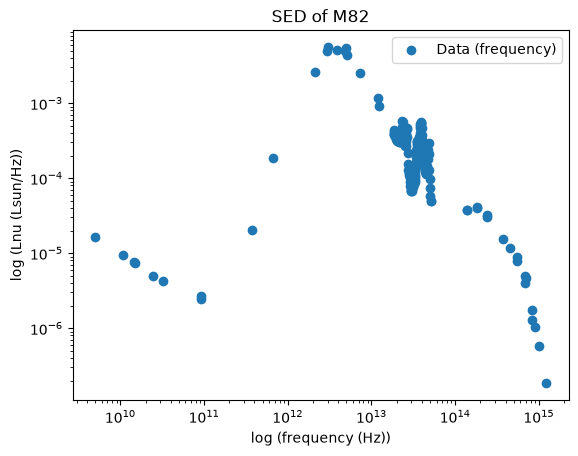

In [16]:
plt.scatter(nu,Lnu, label="Data (frequency)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log (frequency (Hz))")
plt.ylabel("log (Lnu (Lsun/Hz))")
plt.title("SED of M82")
plt.legend()
plt.show()

This is the first plot of the SED of M82 using the data points

In [17]:
data_PAHion_30.head()

,w(micron),Q_ext,Q_abs,Q_sca,g=<cos>
0,1000.0,2.169000e-09,2.169000e-09,6.536000e-23,0.0
1,988.6,2.219000e-09,2.219000e-09,6.844000e-23,0.0
2,977.2,2.270000e-09,2.270000e-09,7.166000e-23,0.0
3,966.1,2.322000e-09,2.322000e-09,7.504000e-23,0.0
4,955.0,2.375000e-09,2.375000e-09,7.857000e-23,0.0


In [18]:
data_PAHion_30.dtypes

w(micron)    float64
Q_ext        float64
Q_abs        float64
Q_sca        float64
g=<cos>      float64
dtype: object

In [19]:
data_PAHion_30.columns

Index(['w(micron)', 'Q_ext', 'Q_abs', 'Q_sca', 'g=<cos>'], dtype='str')

In [20]:
data_PAHion_30.head()
#3.548E-04 = radius(micron) ionized PAH/graphitic solid 

,w(micron),Q_ext,Q_abs,Q_sca,g=<cos>
0,1000.0,2.169000e-09,2.169000e-09,6.536000e-23,0.0
1,988.6,2.219000e-09,2.219000e-09,6.844000e-23,0.0
2,977.2,2.270000e-09,2.270000e-09,7.166000e-23,0.0
3,966.1,2.322000e-09,2.322000e-09,7.504000e-23,0.0
4,955.0,2.375000e-09,2.375000e-09,7.857000e-23,0.0


In [21]:
data_sil_81.head()

,w(micron),Q_abs,Q_sca,g=<cos>
0,1000.0,1.371000e-07,2.530000e-21,0.0
1,944.1,1.538000e-07,3.185000e-21,0.0
2,891.3,1.726000e-07,4.010000e-21,0.0
3,841.4,1.936000e-07,5.048000e-21,0.0
4,794.3,2.173000e-07,6.355000e-21,0.0


In [22]:
def absorption_opacity(data, grain_radius_um, rho_gcm3):
    
    lambda_um = data['w(micron)']
    Qabs      = data['Q_abs']


    a_cm = grain_radius_um * 1e-4          
    kappa = (3.0 * Qabs) / (4.0 * a_cm * rho_gcm3)   

    nu = 2.998e8 / (lambda_um * 1e-6)   
    return nu, kappa



nu_pah, kappa_pah = absorption_opacity(data_PAHion_30, grain_radius_um=0.0005, rho_gcm3=2.2)
nu_sil, kappa_sil = absorption_opacity(data_sil_81, grain_radius_um=0.1, rho_gcm3=3.5)

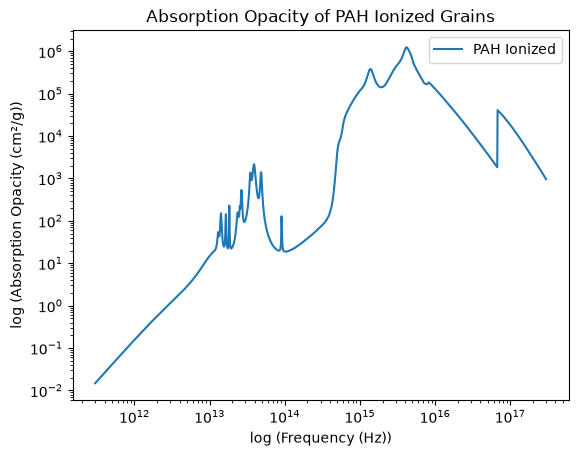

In [23]:
plt.plot(nu_pah, kappa_pah, label="PAH Ionized")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log (Frequency (Hz))")
plt.ylabel("log (Absorption Opacity (cm²/g))")
plt.title("Absorption Opacity of PAH Ionized Grains")
plt.legend()
plt.show()

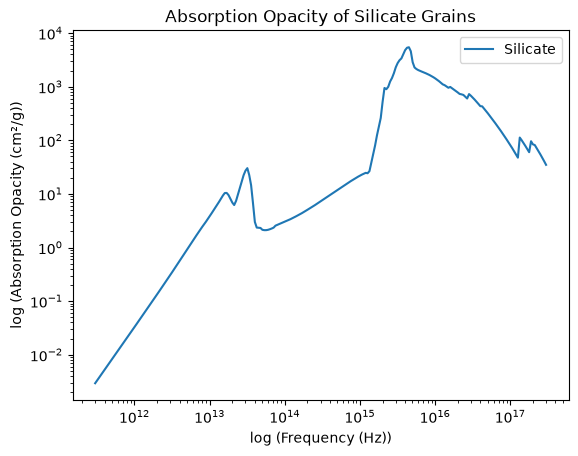

In [24]:
plt.plot(nu_sil, kappa_sil, label="Silicate")
plt.xscale("log")
plt.yscale("log")                               
plt.xlabel("log (Frequency (Hz))")
plt.ylabel("log (Absorption Opacity (cm²/g))")
plt.title("Absorption Opacity of Silicate Grains")
plt.legend()
plt.show()

In [25]:
#nu_plot = np.logspace(np.log10(min(nu)), np.log10(max(nu)), 5000)

### Dust Model

In [26]:
def planck_nu(nu, T):
    h = const.h.value
    k = const.k_B.value
    c = const.c.value

    return (2*h*nu**3 / c**2) / (np.exp(h*nu/(k*T)) - 1)

In [27]:
def absorption_opacity(data, grain_radius_um, rho_gcm3):
    lambda_um = data['w(micron)'].values
    Qabs      = data['Q_abs'].values
    a_cm = grain_radius_um * 1e-4          
    kappa = (3.0 * Qabs) / (4.0 * a_cm * rho_gcm3)   
    nu = const.c.value / (lambda_um * 1e-6)
    return nu, kappa


In [28]:
kappa_sil_plot = np.interp(nu, nu_sil, kappa_sil)
kappa_pah_plot = np.interp(nu, nu_pah, kappa_pah)

T_sil = 38
A_sil = 1.9e+12

T_pah = 402.4
A_pah = 4.8e+04

dust_model_sil = A_sil * kappa_sil_plot * planck_nu(nu, T_sil)
dust_model_pah = A_pah * kappa_pah_plot * planck_nu(nu, T_pah)


/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


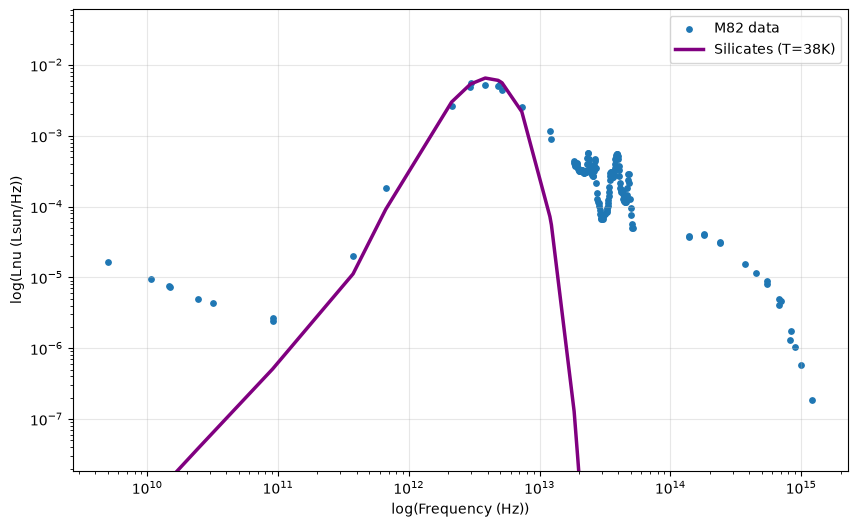

In [29]:
plt.figure(figsize=(10,6))
plt.scatter(nu, Lnu,s=15,label='M82 data')
plt.plot(nu, dust_model_sil, lw=2.5,color='purple', label=f'Silicates (T={T_sil}K)')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*11)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

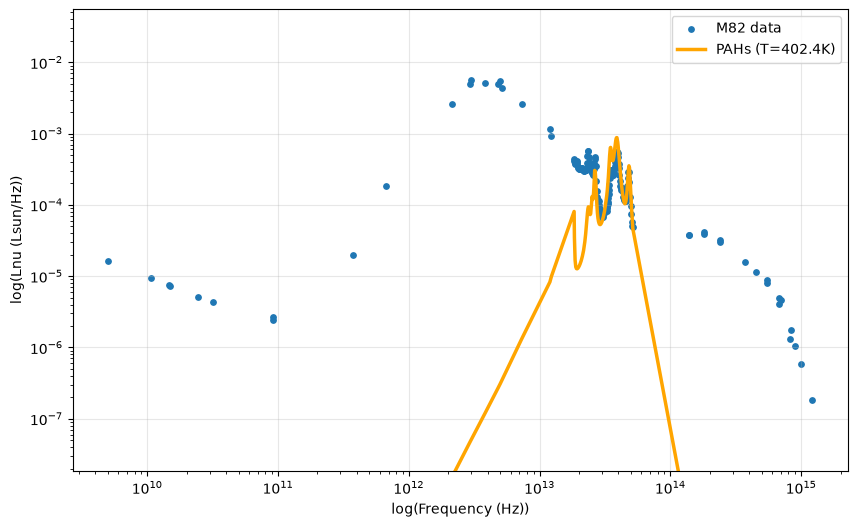

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(nu, Lnu, s=15, label='M82 data')
plt.plot(nu, dust_model_pah, lw=2.5,color="orange", label=f'PAHs (T={T_pah}K)')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*10)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Thermal Bremsstruhlung(Free-Free) Model

In [31]:
def Free_Free(A_ff,Z,ne,ni,Te,nu,g_ff):
    h = const.h.value
    k = const.k_B.value
    return A_ff*6.8e-38*Z**2*ne*ni*Te**-0.5*np.exp(-h*nu/(k*Te))*g_ff

In [142]:
ff_model = Free_Free(A_ff=12.5e14,Z=1, ne=1e10, ni=1e10, Te=9.2107938e3, nu=nu, g_ff=1)

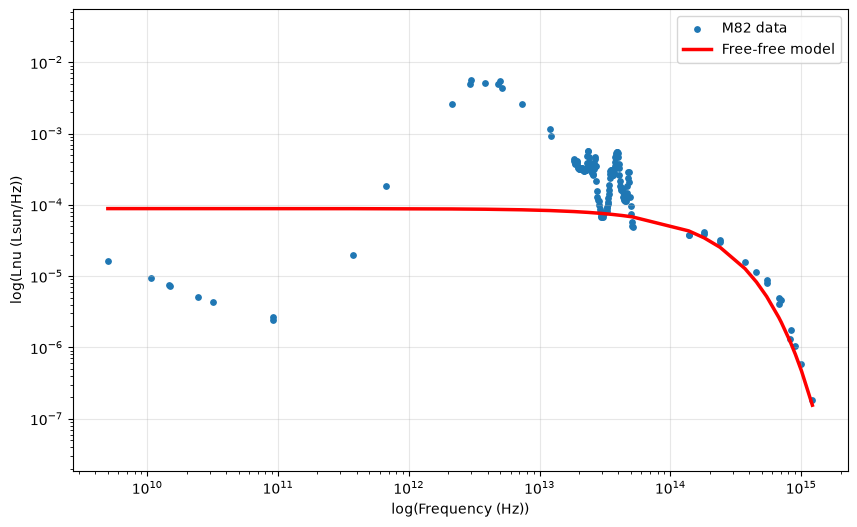

In [143]:
plt.figure(figsize=(10, 6))
plt.scatter(nu, Lnu, s=15, label='M82 data')
plt.plot(nu,ff_model, lw=2.5, color='red', label='Free-free model')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*10)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("free_free_model.png")
plt.show()


In [36]:
print(np.min(Lnu), np.max(Lnu))
print(np.min(ff_model), np.max(ff_model))


1.845e-07 0.005578
6.875274117004837e-10 8.269924009478563e-05


In [37]:
print(nu.min())
print(nu.max())

5000000000.0
1218699186991870.0


### Synchrotron Emission Model

In [38]:
def sync(C,B,alpha,nu,a):
    q = const.e.value
    c = const.c.value
    m_e = const.m_e.value

    return ((np.sqrt(3)*q**3*C*B*np.sin(alpha))/(4*np.pi*m_e*c**2*(a+1)))*(gamma((a/2)+(11/6)))*(gamma((a/2)+(1/6)))*((m_e*c*2*np.pi*nu)/(3*q*B*np.sin(alpha)))**-a

In [39]:
sync_model = sync(C=1.6e+57,B=1e-8,alpha=np.pi/2,nu=nu,a=0.65)

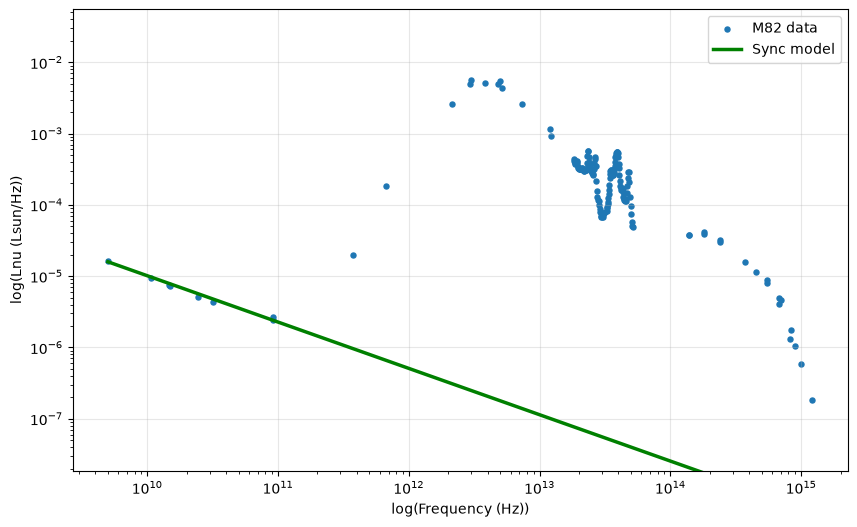

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(nu, Lnu, s=13, label='M82 data')
plt.plot(nu, sync_model, lw=2.5, color='green', label='Sync model')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*10)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("sync_model.png")
plt.show()


In [41]:
print(np.min(sync_model))
print(np.max(sync_model))

5.01366786435819e-09
1.59095463563891e-05


### $\chi$^2  - fitting

In [ ]:
def Chi_square(params):
   A_scale , Te = params
   A_ff = A_scale

   predictions = ff_model = Free_Free(A_ff=A_ff,Z=1, ne=1e10, ni=1e10, Te=Te, nu=nu, g_ff=1)
   residuals = Lnu -predictions


   return np.sum((residuals/sigmaLnu)**2)


In [60]:
initial_guess = [8.6,5e3]

In [61]:
result = minimize(Chi_square, initial_guess)
best_params = result.x
print(best_params[0]*1e14)
print(best_params[1])
print(result.fun)

860000000000000.0
5000.0
62214.94408893874


In [63]:
ff = Free_Free(
    A_ff=8.6e14,
    Z=1,
    ne=1e10,
    ni=1e10,
    Te=5e3,
    nu=nu,
    g_ff=1
)

print("Lnu:", np.min(Lnu), np.max(Lnu))
print("Free-free:", np.min(ff), np.max(ff))
print("sigma:", np.min(sigmaLnu), np.max(sigmaLnu))

Lnu: 1.845e-07 0.005578
Free-free: 6.875274117004837e-10 8.269924009478563e-05
sigma: 2.768e-08 0.000296
